This workbook implements a form of generalised profiling: Logistic growth with synthetic data. 

Matthew J Simpson - QUT

Ruth E Baker - Oxford

December 2025

In [39]:
using Plots, DifferentialEquations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Statistics
using SparseArrays, StatsAPI, LinearAlgebra
gr(); #Load packages 

In [40]:
Tend = 100;
t=LinRange(0,Tend,11);    #Discretised time variable, coarse discretisation for data
tf=LinRange(0,Tend,1001); #Discretised time variable, fine discretisation for ODE enforcing
int = 5;
Kt = 100; λt = 0.1; u0=5.0; σt = 5.0
ue(t) = K*u0/(u0+(K-u0)*exp(-λ*t)); #Exact solution
data = [6.362964340010324
   4.59107677013289
  28.88428228414792
  50.14533908810126
  77.67975821583221
  88.37959353383431
  99.47028537706178
 102.23501244517401
  96.92038422430502
 106.44406333787057
  96.3846677148899]; #Synthetic data

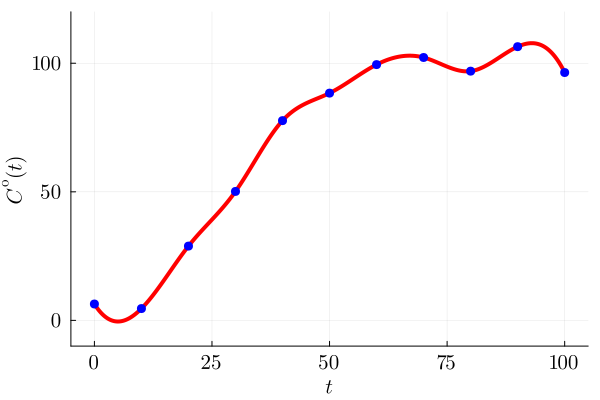

In [41]:
S_interp = interpolate(t, data, BSplineOrder(4)) #Create spline to overfit the data
B = basis(S_interp);                             #Basis functions
Coeff = coefficients(S_interp)                   #Spline coefficients

Csp = collocation_matrix(B, t, Derivative(0), SparseMatrixCSC{Float64, Int});    #Collocation matrix for the function on the coarse grid
Cspf = collocation_matrix(B, tf, Derivative(0), SparseMatrixCSC{Float64, Int});  #Collocation matrix for the function on the fine grid
C1spf = collocation_matrix(B, tf, Derivative(1), SparseMatrixCSC{Float64, Int}); #Collocation matrix for the first derivative on the fine grid

C  = Csp*Coeff;   #Evaluate spline for the function on the coarse grid
Cf  = Cspf*Coeff  #Evaluate spline for the function on the fine grid
dCf = C1spf*Coeff #Evaluate spline for the first derivative on the fine grid

p1 = plot(tf,Cf,lw=4,lc=:red,label=false) #Plot results
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p1)
#savefig("f4a.svg")

In [42]:
function loglhood(data,C,Cf,dCf,t,tf,w,a) #Function to evaluate the loglikelihood of the data stored in the vector data.  
    
ℓ =0; ℓd =0; ℓm =0;    
dist=Normal(0,a[3]) 
ℓd+=loglikelihood(dist,data-C)  
ℓm = sum((dCf .- a[1] .*Cf .*(1.0 .- Cf/a[2])  ).^2) / length(tf) 
ℓ = w[1]*ℓd - w[2]*ℓm;
return ℓ

end;

In [43]:
function Optimise(fun,θ₀,lb,ub) #Optimize finds the values of parameters \theta that maximise the objective function fun with lower bounds lb, and upper bounds ub
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = optimize(opt,θ₀)
    return res[[2,1]]
end

Optimise (generic function with 1 method)

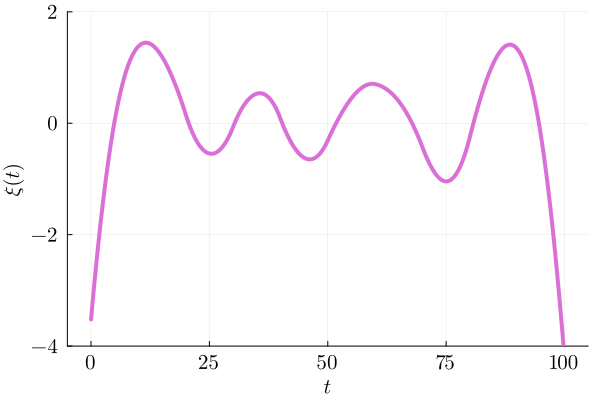

In [44]:
λmin=0.01; λmax=2;  Kmin=80; Kmax=120;  σmin = 0.1; σmax=10;  #Lower/upper bounds
θG=[λt, Kt, σt] #Iniitial estimate of the parameter values
lb=[λmin,Kmin,σmin]
ub=[λmax,Kmax,σmax]
a = zeros(3);
w = [1,1];
funopt(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ1,fopt)=Optimise(funopt,θG,lb,ub) #Call to NLopt to provide the first estimate of the parameters 
a1 = plot(tf,dCf - θ1[1]*Cf.*(1.0 .- Cf/θ1[2]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)

Iteration 2

In [45]:
ℓd=0; ℓm =0
ℓd+=loglikelihood(Normal(0,θ1[3]) ,data-C);
ℓm = sum((dCf .- θ1[1].*Cf.*(1.0 .- Cf/θ1[2])).^2) / length(tf);
w = [1.0,abs(1/ℓm)];
funopt2(a) = loglhood(data,C,Cf,dCf, t, tf,w, a) #Here setting the weight to one
(θ2,fopt)=Optimise(funopt2,θG,lb,ub) #Call to NLopt 

([0.10414790262777715, 101.7543077826632, 0.1], 14.2201121576831)

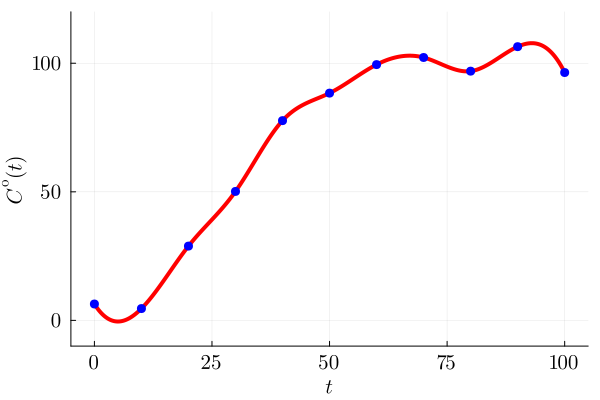

In [46]:
d0=data; d1=zeros(length(tf));
d1 = [θ2[1]*Cf[i]*(1.0 - Cf[i]/θ2[2]) for i in eachindex(tf) ]

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)
p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [47]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ2[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ2[1].*Cf.*(1.0 .- Cf/θ2[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 5400.436999900217
Model distance 0.081649548227645


Iteration 3

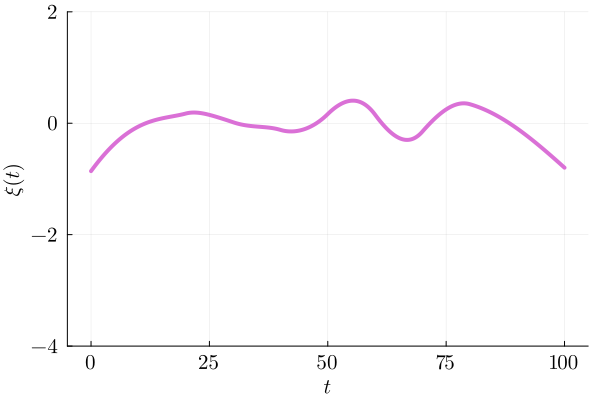

In [48]:
funopt3(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ3,fopt)=Optimise(funopt3,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ3[1]*Cf.*(1.0 .- Cf/θ3[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

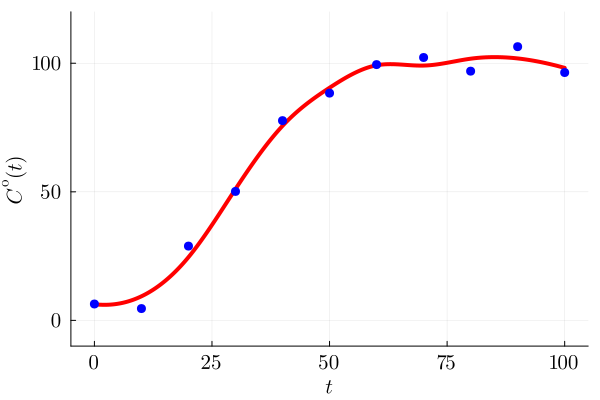

In [49]:
d1 = [θ3[1]*Cf[i]*(1.0 - Cf[i]/θ3[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [50]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ3[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ3[1].*Cf.*(1.0 .- Cf/θ3[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 31.412719765954513
Model distance 0.025669656513972777


Iteration 4

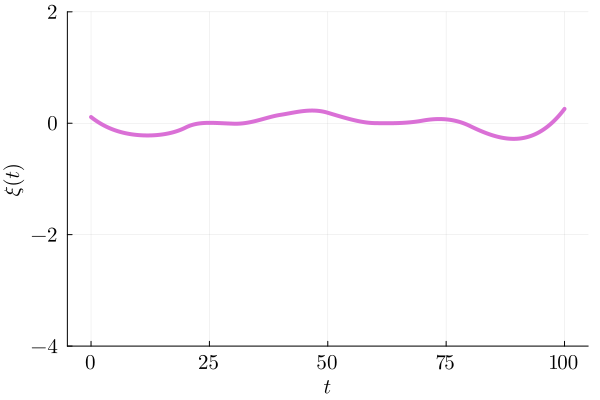

In [51]:
funopt4(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ4,fopt)=Optimise(funopt4,θG,lb,ub) #Call to NLopt 

a1 = plot(tf,dCf - θ4[1]*Cf.*(1.0 .- Cf/θ4[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

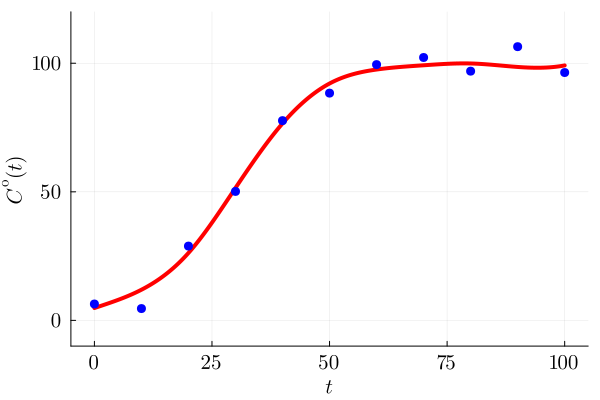

In [52]:
d1 = [θ4[1]*Cf[i]*(1.0 - Cf[i]/θ4[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [53]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ4[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ4[1].*Cf.*(1.0 .- Cf/θ4[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 31.232594791199503
Model distance 0.012470918103624795


Iteration 5

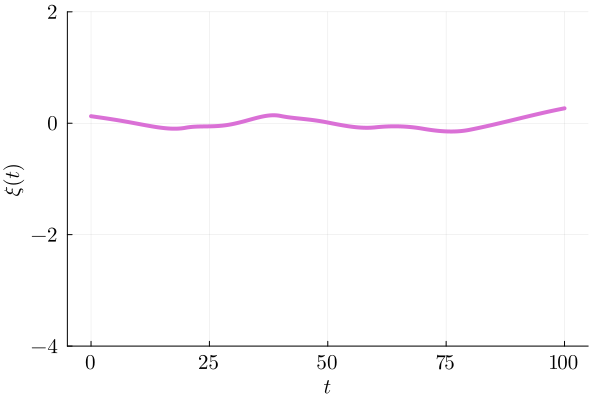

In [54]:
funopt5(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ5,fopt)=Optimise(funopt5,θG,lb,ub) #Call to NLopt

a1 = plot(tf,dCf - θ5[1]*Cf.*(1.0 .- Cf/θ5[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

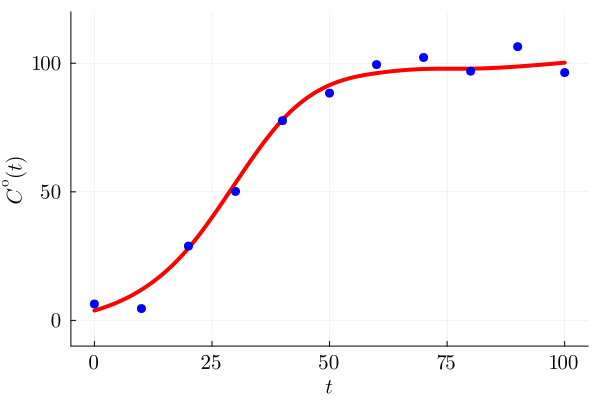

In [55]:
d1 = [θ5[1]*Cf[i]*(1.0 - Cf[i]/θ5[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [56]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ5[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ5[1].*Cf.*(1.0 .- Cf/θ5[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 30.44135978306589
Model distance 0.007579410463138728


Iteration 6

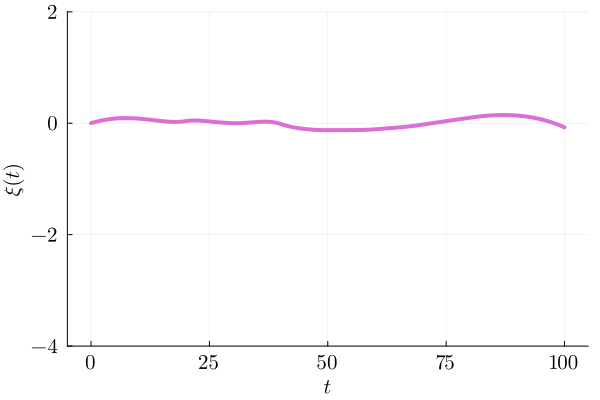

In [57]:
funopt6(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ6,fopt)=Optimise(funopt6,θG,lb,ub) #Call to NLopt

a1 = plot(tf,dCf - θ6[1]*Cf.*(1.0 .- Cf/θ6[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

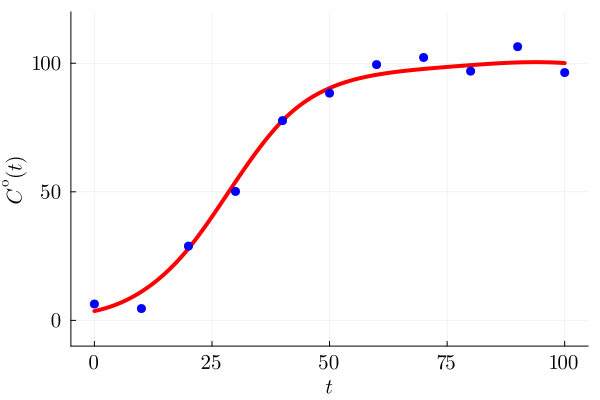

In [58]:
d1 = [θ6[1]*Cf[i]*(1.0 - Cf[i]/θ6[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [59]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ6[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ6[1].*Cf.*(1.0 .- Cf/θ6[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 29.592017512336593
Model distance 0.007279431645235602


Iteration 7

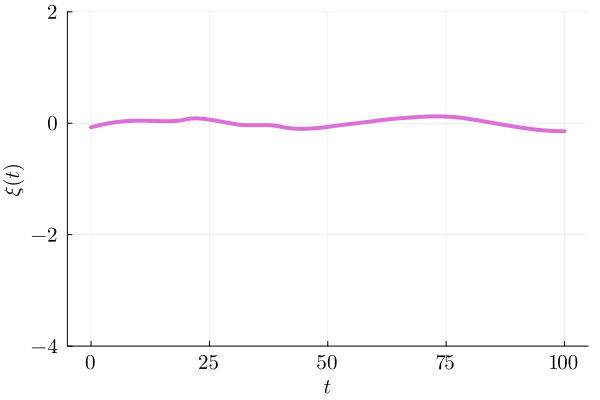

In [60]:
funopt7(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ7,fopt)=Optimise(funopt7,θG,lb,ub) #Call to NLopt

a1 = plot(tf,dCf - θ7[1]*Cf.*(1.0 .- Cf/θ7[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

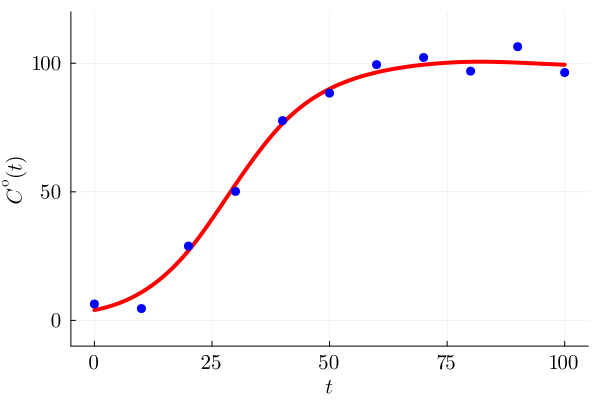

In [61]:
d1 = [θ7[1]*Cf[i]*(1.0 - Cf[i]/θ7[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [62]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ7[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ7[1].*Cf.*(1.0 .- Cf/θ7[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 29.91098901369555
Model distance 0.004407919196706936


Iteration 8

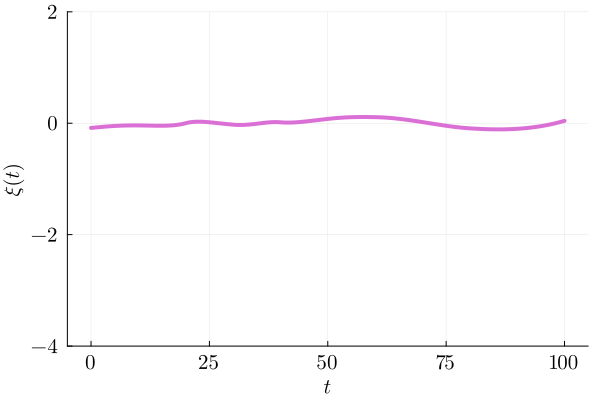

In [63]:
funopt8(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ8,fopt)=Optimise(funopt8,θG,lb,ub) #Call to NLopt

a1 = plot(tf,dCf - θ8[1]*Cf.*(1.0 .- Cf/θ8[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

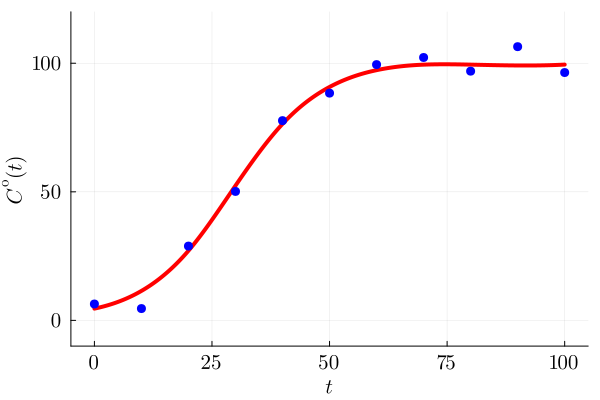

In [64]:
d1 = [θ8[1]*Cf[i]*(1.0 - Cf[i]/θ8[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [65]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ8[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ8[1].*Cf.*(1.0 .- Cf/θ8[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 30.629471646633487
Model distance 0.004621756117771976


Iteration 9

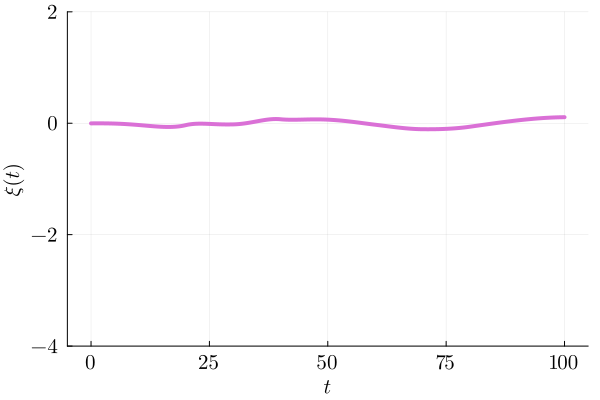

In [66]:
funopt9(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ9,fopt)=Optimise(funopt9,θG,lb,ub) #Call to NLopt

a1 = plot(tf,dCf - θ9[1]*Cf.*(1.0 .- Cf/θ9[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

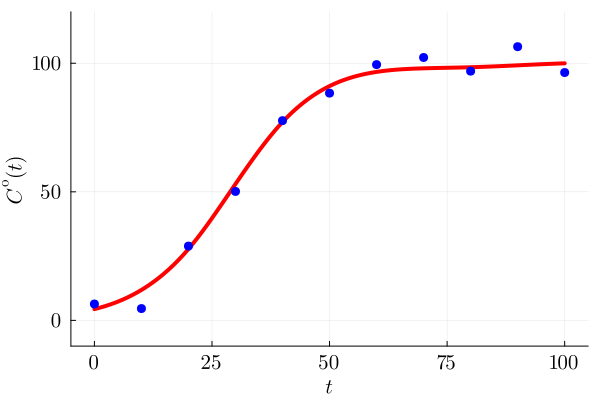

In [67]:
d1 = [θ9[1]*Cf[i]*(1.0 - Cf[i]/θ9[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [68]:
C = Csp*Coeff; Cf = Cspf*Coeff; dCf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ9[3]) ,data-C)  
ℓm =0;
ℓm = sum((dCf .- θ9[1].*Cf.*(1.0 .- Cf/θ9[2])).^2) / length(tf)

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 30.413868338001134
Model distance 0.0031239272544935355


Iteration 10

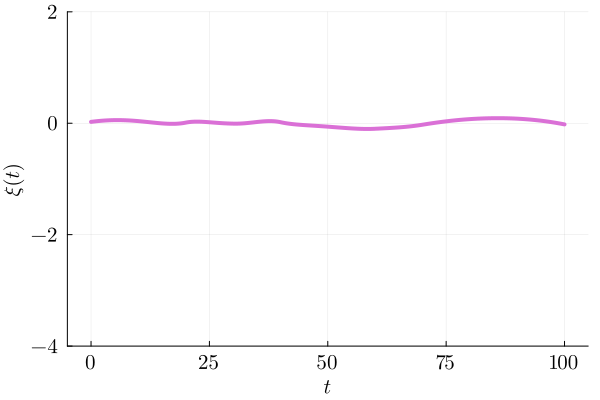

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f4c.svg"

In [69]:
funopt10(a) = loglhood(data,C,Cf,dCf, t, tf, w, a) #Here setting the weight to one
(θ10,fopt)=Optimise(funopt10,θG,lb,ub) #Call to NLopt

a1 = plot(tf,dCf - θ10[1]*Cf.*(1.0 .- Cf/θ10[2]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5),ylims=(-4,2),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2],[L"-4", L"-2", L"0", L"2"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(a1)
savefig("f4c.svg")

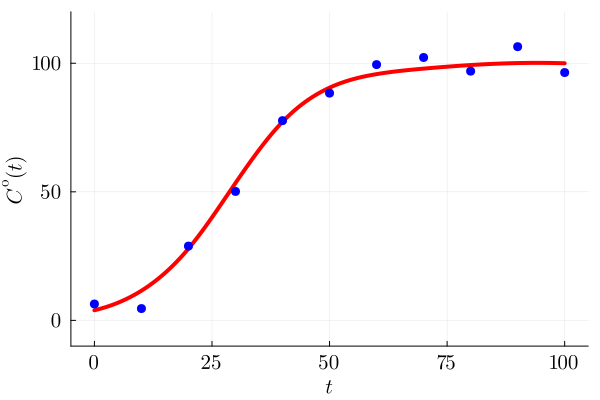

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f4d.svg"

In [70]:
d1 = [θ10[1]*Cf[i]*(1.0 - Cf[i]/θ10[2]) for i in eachindex(tf) ]
Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cf; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-10,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)
savefig("f4d.svg")

In [71]:
Cf[1]

3.9356839227555107

In [72]:
ue(t) = θ10[2]*Cf[1]/(Cf[1]+(θ10[2]-Cf[1])*exp(-θ10[1]*t))

ue (generic function with 1 method)

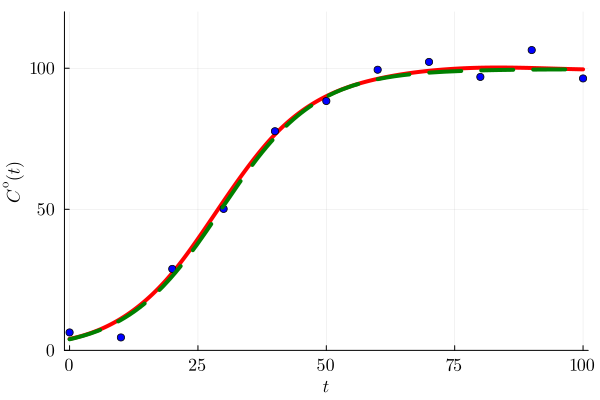

In [73]:
p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:match,label=false)
p4=plot!(xlabel=L"t",ylabel=L"C^{\textrm{o}}(t)",color=:red,xlims=(t[1]-1,t[end]+1), ylims=(0,120),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100],[L"0", L"50", L"100"]),label=false)
p4=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
p4=plot!(ue,0,Tend,lw=4,lc=:green,ls=:dash,legend=false)
display(p4)

In [74]:
θ1

3-element Vector{Float64}:
   0.10414790268147647
 101.7543075849453
   0.1

In [75]:
θ5

3-element Vector{Float64}:
  0.11070680252077453
 99.20272957727367
  4.1304487620542965

In [76]:
θ10

3-element Vector{Float64}:
  0.1082700926482556
 99.65771220715791
  3.8409205908099024